## 1. La legge dei grandi numeri

La legge dei grandi numeri è un teorema fondamentale della teoria della probabilità che indica che se ripetiamo molte volte (tendendo all'infinito) lo stesso esperimento, la frequenza di un certo evento tende ad essere costante.

Vale a dire, **la legge dei grandi numeri indica che se lo stesso test viene eseguito ripetutamente (ad esempio, lancio di una moneta), la frequenza con cui si ripeterà un determinato evento (testa/croce) si avvicinerà a una costante. Questa a sua volta sarà la probabilità che questo evento si verifichi.**

Fonte: https://it.economy-pedia.com/11038376-law-of-the-big-numbers

- Scrivere una funzione che simula il lancio di una moneta per N volte e restituisce la frequenza % di volte che è uscita testa.
- Calcolare la frequenza % con la grandezze del campione (numero di lanci) che varia 100 volte da 10 a 20000. Ottengo quindi 100 valori.
- Fare il plot del Numero medio di teste (y) rispetto alla grandezza del campione (x)





In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
vec_prob = [1/2, 1/2]
def funzione (vec_prob, n):
    return np.random.choice(a=[0,1], size=n, replace=True, p=vec_prob)
    
campione = np.array([round(np.sum(np.random.choice(a=[0,1], size=i, p=[1/2, 1/2]) / i), 3) for i in range(10, 20000+1, 100)])
plt.plot(np.arange(10, 20000+1, 100), campione)
plt.axhline(0.5, color="red", linestyle="--")

## 2. Analisi del Dataset Titanic
- Quante righe e colonne ha il dataset?
- Controlla quanti valori mancanti ci sono per colonna
- Riempi i valori mancanti nella colonna 'Embarked' con il valore più frequente
- Controlla se ci sono righe duplicate
- Calcola l'età media dei passeggeri per ogni classe (`Pclass`), se ci sono valori mancanti di età nella colonna 'Age' riempili con il valore medio
- Visualizza la distribuzione dell'età per classe
- Visualizza la distribuzione dell'età per classe dividendo e mostrando insieme i dati di uomini e donne

In [1]:
# 📦 Caricamento del dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "titanic.csv"
df = pd.read_csv(url)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
print("#1 righe e colonne data frame: ", df.shape)
print("#2 quanti null per colonna:")
print(df.isnull().sum())
#3 riempi i null da `Embarked`
most_common = df["Embarked"].mode()[0]
df['Embarked'] = df['Embarked'].fillna(most_common)
print("#4 Numero di duplicati")
print(df.duplicated().sum())
print("#5. Età media dei passeggeri per ogni classe")
df['Age'] = df['Age'].fillna(df.groupby('Pclass')['Age'].transform('mean'))
print(df.groupby(by="Pclass")['Age'].mean().round(3))

#1 righe e colonne data frame:  (891, 12)
#2 quanti null per colonna:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
#4 Numero di duplicati
0
#5. Età media dei passeggeri per ogni classe
Pclass
1    38.233
2    29.878
3    25.141
Name: Age, dtype: float64


Pclass
1    Axes(0.125,0.11;0.775x0.77)
2    Axes(0.125,0.11;0.775x0.77)
3    Axes(0.125,0.11;0.775x0.77)
Name: Age, dtype: object

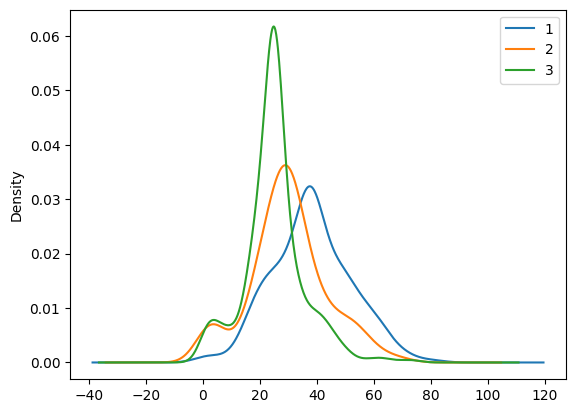

In [3]:
df.groupby('Pclass')['Age'].plot.kde(legend=True)

<Axes: xlabel='Age', ylabel='Count'>

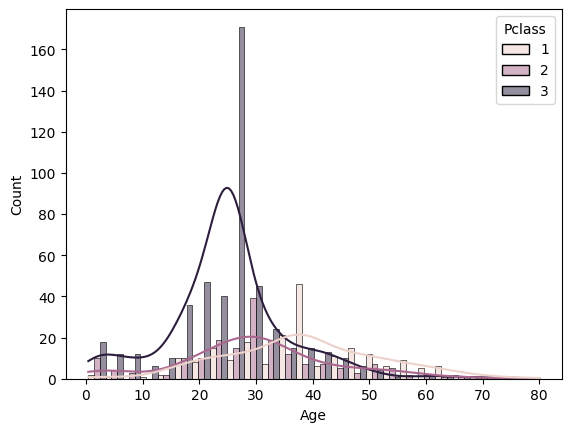

In [4]:
sns.histplot(data=df, x='Age', hue='Pclass', multiple='dodge', kde=True)

<Axes: xlabel='Age', ylabel='Density'>

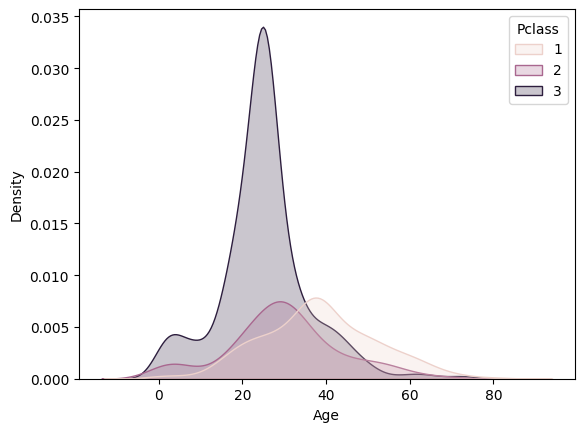

In [5]:
sns.kdeplot(data=df, x='Age', hue='Pclass', fill=True)

<Axes: xlabel='Pclass', ylabel='Age'>

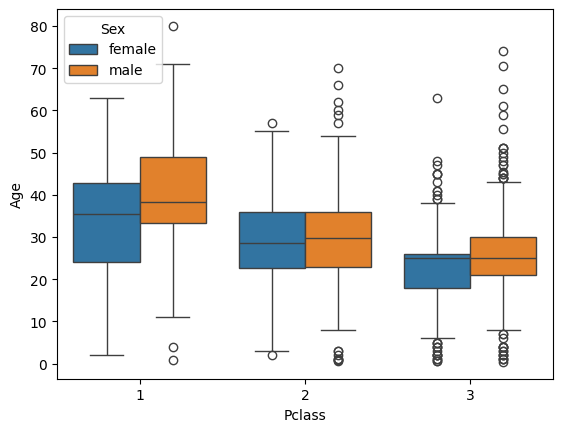

In [ ]:
# - Calcola l'età media dei passeggeri per ogni classe (`Pclass`), se ci sono valori mancanti di età nella colonna 'Age' riempili con il valore medio
# - Visualizza la distribuzione dell'età per classe
# - Visualizza la distribuzione dell'età per classe dividendo e mostrando insieme i dati di uomini e donne
sns.boxplot(data=df, x='Pclass', y='Age', hue='Sex')

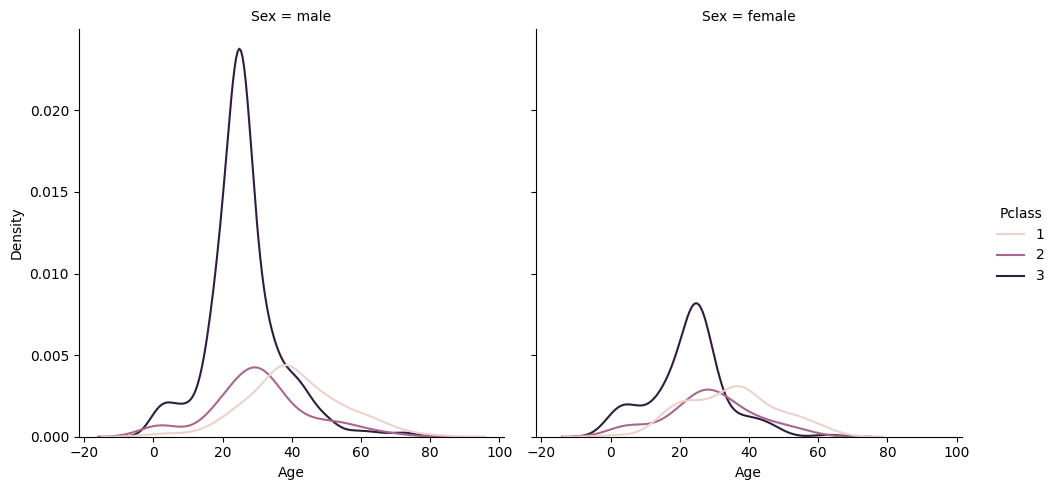

In [17]:
sns.displot(data=df, x='Age', hue='Pclass', col='Sex', kind='kde')

## 3. Analisi del Dataset Iris

- Esplora la distribuzione delle specie (conta quanti campioni ci sono per specie)
- Calcola la lunghezza e la larghezza media dei petali per specie
- Visualizza le dimensioni dei petali per specie (scatterplot)
- Crea una nuova colonna per l'area del petalo e analizzala
- Grafico della distribuzione dell'area del petalo per specie (boxplot)

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
df = pd.read_csv(url)
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [21]:
df.index.name = 'id'
print("#1 quanti campioni per specie:")
print(df['species'].value_counts())
print("#2 lunghezza e larghezza media dei petali per specie")
print(df.groupby('species')[['petal_length', 'petal_width']].mean())

#1 quanti campioni per specie:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64
#2 lunghezza e larghezza media dei petali per specie
            petal_length  petal_width
species                              
setosa             1.462        0.246
versicolor         4.260        1.326
virginica          5.552        2.026


#3 dimensioni petali per specie tramite scatterplot:


<Axes: xlabel='petal_length', ylabel='petal_width'>

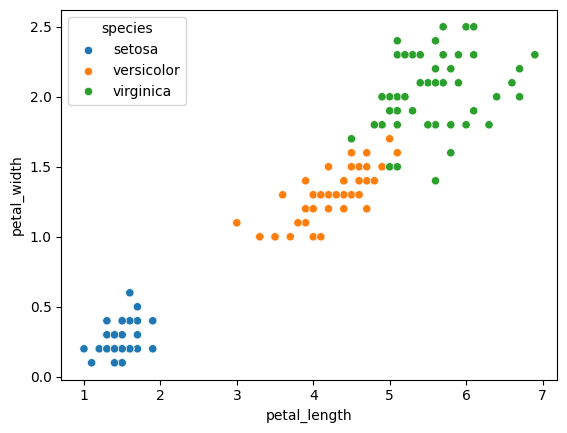

In [23]:
print("#3 dimensioni petali per specie tramite scatterplot:")
sns.scatterplot(data=df, x='petal_length', y='petal_width', hue='species')

In [16]:
print("#4 crea colonna area del petalo e analisi con numero campionim, somma delle aree, medie per ogni specie")
df['petal_area'] = df['petal_length'] * df['petal_width']
print(df.groupby('species')['petal_area'].agg(['count', 'sum', 'mean']))

#4 crea colonna area del petalo e analisi con numero campionim, somma delle aree, medie per ogni specie
            count     sum     mean
species                           
setosa         50   18.28   0.3656
versicolor     50  286.02   5.7204
virginica      50  564.81  11.2962


#5 grafico della distribuzione dell'area del petalo per specie tramite boxplot


<Axes: xlabel='species', ylabel='petal_area'>

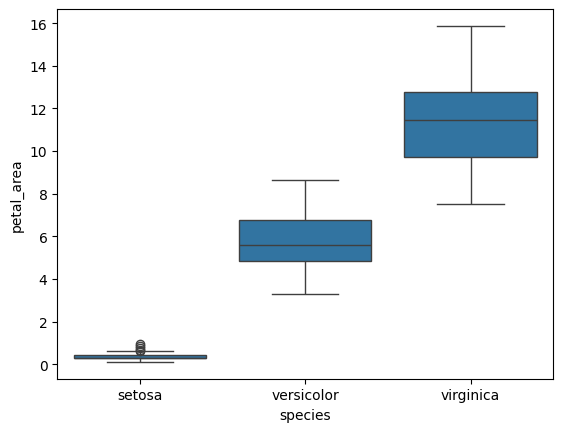

In [22]:
print("#5 grafico della distribuzione dell'area del petalo per specie tramite boxplot")
sns.boxplot(data=df, x='species', y='petal_area')